In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/dsml_pandas/titanic (1).csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Cleaning**

In [4]:
# Renaming Columns
df.rename(columns={"Pclass": "Pstatus"}, inplace = True)
df

,PassengerId,Survived,Pstatus,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.rename(columns={"Sex": "Gender"}, inplace = True)
df

,PassengerId,Survived,Pstatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**Handling Incorrect Data**

In [11]:
# Handling Incorrect Data
import numpy as np
data = pd.DataFrame({
    "id": [1,3,5,7,9],
    "name": ["John", "Jane", "Jennifer", "Johan", "Jeff"],
    "age": [25,-32,19,42,"55"],
    "gender": ["M","M", "Z", "F","F"],
    "income": [400, 700, 300, np.nan, 600]
    })

In [12]:
data = data.astype({
    "age": int
})
data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,-32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,42,F,NaN
4,9,Jeff,55,F,600.0


In [13]:
data["age"] = abs(data["age"])
data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,42,F,NaN
4,9,Jeff,55,F,600.0


In [14]:
data= data.fillna({"income": 0}).astype({"income": int})
data


,id,name,age,gender,income
0,1,John,25,M,400
1,3,Jane,32,M,700
2,5,Jennifer,19,Z,300
3,7,Johan,42,F,0
4,9,Jeff,55,F,600


In [15]:
data.dtypes

,0
id,int64
name,object
age,int64
gender,object
income,int64


In [16]:
data["age"].dtype

dtype('int64')

In [19]:
# boundary
filter_age = data[(data["age"] > 18) & (data["age"] < 45)]
filter_age

,id,name,age,gender,income
0,1,John,25,M,400
1,3,Jane,32,M,700
2,5,Jennifer,19,Z,300
3,7,Johan,42,F,0


 .isin() to filter to the Dataframe


In [20]:
data[data.gender.isin(["M", "F"])]
# .isin() to filter to the Dataframe


,id,name,age,gender,income
0,1,John,25,M,400
1,3,Jane,32,M,700
3,7,Johan,42,F,0
4,9,Jeff,55,F,600


**Saving a dataframe**

In [21]:
# Saving a dataframe
data.to_csv()


',id,name,age,gender,income\n0,1,John,25,M,400\n1,3,Jane,32,M,700\n2,5,Jennifer,19,Z,300\n3,7,Johan,42,F,0\n4,9,Jeff,55,F,600\n'

In [22]:
data.to_csv("clean_data.csv", index =False)

In [23]:
# If we need in json
data.to_json("clean_data.json", index = False, orient = "records")

In [24]:
data.to_json("clean_data1.json", index = False, orient = "table")

**Chi-Square (χ²) test**

The Chi-Square (χ²) test is a statistical test used in data science to determine whether there is a significant relationship between categorical variables or whether the observed data differs from what we would expect by chance

What does Chi-Square do?

Imagine you have two categorical variables:

Gender (Male, Female)
Purchased Product (Yes, No)

You want to know:

Does gender affect whether someone buys the product?

Instead of guessing, the Chi-Square test compares:

Observed values → What actually happened
Expected values → What would happen if there were no relationship

If the observed values differ greatly from the expected values, then the variables are likely related.

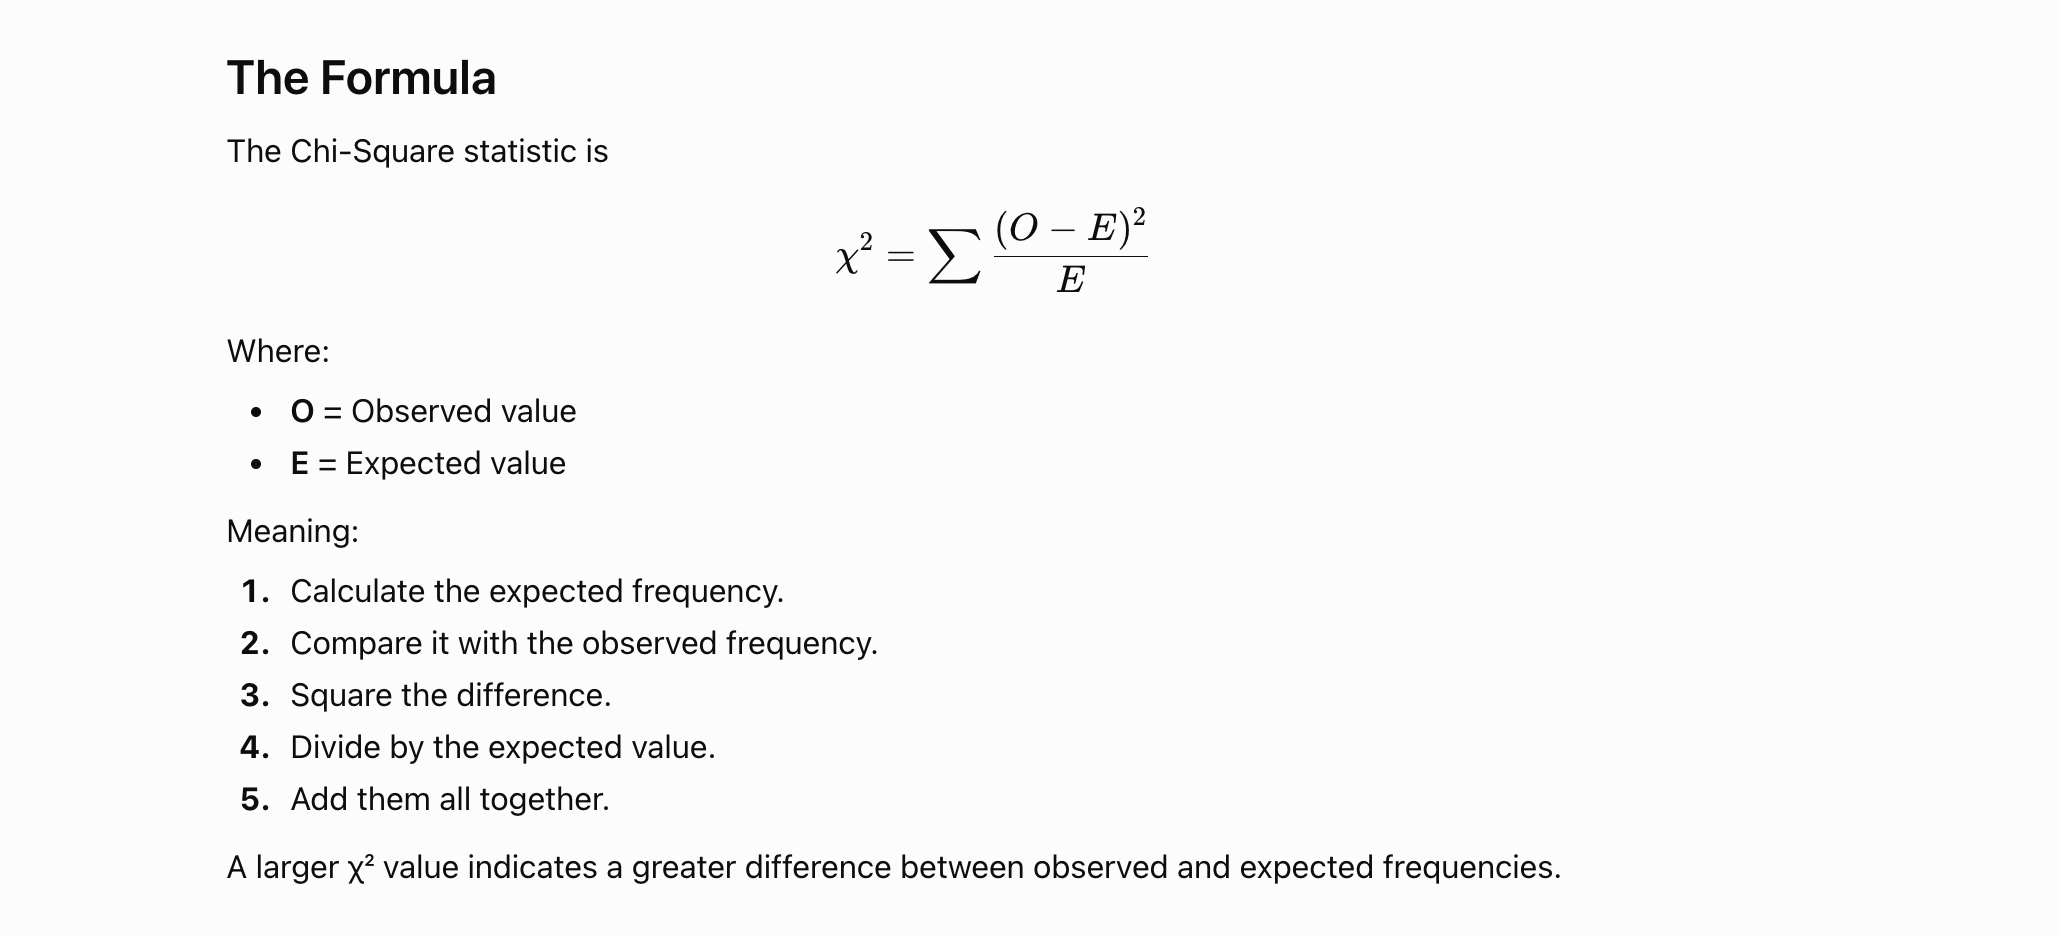

The Chi-Square test is a statistical method used to determine whether categorical variables are associated, and in data science it is widely used for feature selection and hypothesis testing to identify which categorical features are most relevant to a target variable.

**Is Gender related to Purchase?**

In [25]:
import pandas as pd
data = {
    "Gender": ["Male", "Male", "Male", "Female", "Female", "Female", "Male", "Female", "Male", "Femalea"],
    "Purchased": ["Yes", "No", "Yes", "No", "Yes", "No", "Yes", "No", "Yes", "Yes"]
}
df = pd.DataFrame(data)
print(df)


    Gender Purchased
0     Male       Yes
1     Male        No
2     Male       Yes
3   Female        No
4   Female       Yes
5   Female        No
6     Male       Yes
7   Female        No
8     Male       Yes
9  Femalea       Yes


**Create a Contingency Table**

In [26]:
contingency_table = pd.crosstab(df["Gender"], df["Purchased"])

In [27]:
contingency_table

Purchased,No,Yes
Gender,,
Female,3,1
Femalea,0,1
Male,1,4


**Degrees** **of** **Freedom** **tells** **us** **how** **many** **values** **are** **free** **to** **vary** **when** **calculating** **the** **Chi**-**Square** **statistic**.

**Formula**:

(rows−1)×(columns−1)

**Perform** **Chi**-**Square** **Test**


In [28]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)


In [31]:
print("Chi-square statics:", chi2)
print("P-value", p)
print("Degree of freedom:", dof)
print("Expected frequencies:")
print(expected)


Chi-square statics: 3.5416666666666665
P-value 0.17019110379502855
Degree of freedom: 2
Expected frequencies:
[[1.6 2.4]
 [0.4 0.6]
 [2.  3. ]]


In [33]:
# Decision
alpha = 0.05
if p < alpha:
  print("There is a significant relationship.")
else:
  print("No significant relationship.")

No significant relationship.


**Example** **2**: **Feature** **Selection** **using** **Chi**-**Square**


In [37]:
import pandas as pd
data1 = {
    "Gender": [0,1,0,1,0,1,0,1],
    "City": [0,1,0,0,1,1,0,1],
    "Student": [1,1,0,1,0,0,1,1],
    "Purchased": [1,1,0,1,0,0,1,1]
}
df = pd.DataFrame(data1)
X = df.drop("Purchased", axis =1)
y = df["Purchased"]

In [38]:
X

,Gender,City,Student
0,0,0,1
1,1,1,1
2,0,0,0
3,1,0,1
4,0,1,0
5,1,1,0
6,0,0,1
7,1,1,1


In [39]:
y

,Purchased
0,1
1,1
2,0
3,1
4,0
5,0
6,1
7,1


**Calculate** **Chi**-**Square** **Scores**

In [40]:
from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(X, y)

for feature, score, p in zip(X.columns, chi_scores, p_values):
    print(f"{feature}")
    print(f"Chi2 Score = {score:.3f}")
    print(f"P-value = {p:.3f}")
    print()

Gender
Chi2 Score = 0.267
P-value = 0.606

City
Chi2 Score = 0.267
P-value = 0.606

Student
Chi2 Score = 3.000
P-value = 0.083



**Example 4: Real Dataset (Titanic)**

In [56]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2

# Load Titanic dataset
df = pd.read_csv("titanic (1) (1).csv")

# Select features
X = df[["Pclass", "Sex", "Embarked"]].copy()

# Encode categorical variables
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Embarked"] = X["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Check missing values
print(X.isnull().sum())

# Fill missing values
X = X.fillna(0)

# Target variable
y = df["Survived"]

# Chi-Square test
selector = SelectKBest(score_func=chi2, k=2)
selector.fit(X, y)

for feature, score in zip(X.columns, selector.scores_):
    print(feature, ":", score)

Pclass      0
Sex         0
Embarked    2
dtype: int64
Pclass : 30.873699436634034
Sex : 170.34812709177143
Embarked : 11.353116844141717
